# 01 — EDA (Home Credit Default Risk)

**Objetivo:** caracterizar en profundidad `application_*`: `TARGET` y baselines ingenuos, tipos y cardinalidad, nulos globales y **nulos por clase `TARGET`**, alineación train/test, **deriva (KS)** en numéricas, IDs, volumetría de tablas auxiliares, sanity checks y percentiles, correlaciones y **heatmap**, categóricas (**Cramér V**), tasas de default por grupo, **EXT_SOURCE** por clase, y **bureau** (filas por cliente vs default). Modelado en notebooks posteriores.

**Problema:** predecir incumplimiento (`TARGET`=1). Métrica Kaggle: **ROC-AUC**.

**Estructura:** la siguiente celda (**Índice**) enlaza las 12 partes numeradas del notebook en el orden lógico del análisis (de datos y calidad a EDA y cierre).

**Cómo está documentado:** debajo de cada sección temática, hay una celda **"Documentación — …"** justo **antes** del código asociado; resume qué hace ese bloque, qué objetos usa y qué debes interpretar en las salidas o gráficos.

**Sobre salidas (outputs) y acceso:** si ejecutas el notebook y **guardas** el archivo `.ipynb`, tablas y figuras quedan embebidas en el JSON del notebook. Cualquier herramienta que **lea ese archivo** (incluido un asistente con acceso al workspace) puede ver esas salidas **tal como están guardadas**. No hay acceso a la ejecución en vivo ni a resultados que no estén guardados en el archivo.


## Índice

Flujo del notebook: contexto y datos → calidad y coherencia train/test → volumetría y rangos → asociación con `TARGET` y tablas auxiliares → auditoría de leakage → reproducibilidad → EDA uni/bi/multi → análisis avanzado → cierre.

| # | Sección |
|---|--------|
| 1 | [Fuentes de datos](#sec-1) |
| 2 | [Tabla principal `application_*`](#sec-2) |
| 3 | [Valores faltantes](#sec-3) |
| 4 | [Calidad: duplicados e IDs](#sec-4) |
| 5 | [Otras tablas (volumen)](#sec-5) |
| 6 | [Rangos plausibles (sanity checks)](#sec-6) |
| 7 | [Asociación con `TARGET`](#sec-7) |
| 8 | [Auditoría preliminar de leakage](#sec-8) |
| 9 | [Reproducibilidad](#sec-9) |
| 10 | [EDA univariado, bivariado y multivariado](#sec-10) |
| 11 | [EDA premium (estadística avanzada)](#sec-11) |
| 12 | [Resumen y siguientes pasos](#sec-12) |

Las celdas **Documentación — …** preceden cada bloque de código y explican qué hace ese bloque.


<a id="sec-1"></a>
## 1. Fuentes de datos


| Recurso | Uso |
|--------|-----|
| `data/raw/*.csv` | CSV de la competición |
| `configs/home_credit.yaml` | Archivos, claves, `TARGET` |
| `configs/base.yaml` | Semilla, splits |
| `HomeCredit_columns_description.csv` | Diccionario de columnas |

Código: `src.data.home_credit`.


### Documentación — Configuración e imports

- **`sys.path` / `ROOT`**: permite importar el paquete `src` aunque el kernel se ejecute desde `notebooks/` o la raíz del repo.
- **Librerías**: `numpy`, `pandas`, `matplotlib`, `yaml`; **`scipy.stats`**: `chi2_contingency` (tablas de contingencia) y `ks_2samp` (comparar distribuciones train vs test).
- **`IPython.display.display`**: muestra tablas en el notebook.
- **`src.data.home_credit`**: lectura de CSV y rutas según `configs/home_credit.yaml`.
- **`src.data.quality`**: funciones de calidad (`missing_summary`, `basic_range_checks`).
- **`set_seed(42)`**: alinea con `configs/base.yaml` para muestreos reproducibles en celdas posteriores.
- **Salida**: imprime la raíz del proyecto resuelta por `project_root()`.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from scipy.stats import chi2_contingency, ks_2samp # test Kolmogorov-Smirnov

ROOT = Path.cwd().resolve()
if not (ROOT / "pyproject.toml").exists() and (ROOT.parent / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from IPython.display import display

from src.data.home_credit import keys, read_table, table_path, target_column
from src.data.quality import basic_range_checks, missing_summary
from src.utils.paths import project_root
from src.utils.seed import set_seed

plt.style.use("ggplot")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 120)

set_seed(42)
print("project_root:", project_root())


project_root: E:\Proyectos\Competencias\Home credit\risk-modeling-q1


### Documentación — Carga de `application_train` / `application_test`

- **`read_table`**: lee los CSV completos desde `data/raw/` (rutas definidas en config).
- **`y_col`**: nombre de la columna objetivo (`TARGET`), solo presente en train.
- **`k_curr`**: nombre de la clave primaria (`SK_ID_CURR`) para joins y comprobaciones.
- **Salida**: dimensiones de ambos DataFrames y comprobación de que `TARGET` no está en test.


In [2]:
train = read_table("application_train")
test = read_table("application_test")

y_col = target_column()
k_curr = keys()["sk_id_curr"]

print("train:", train.shape, "| test:", test.shape)
print("TARGET en train:", y_col in train.columns)
print("TARGET en test:", y_col in test.columns)


train: (307511, 122) | test: (48744, 121)
TARGET en train: True
TARGET en test: False


### Interpretación de resultados — Sección 1

- Si `train` y `test` cargan con dimensiones esperadas y `TARGET` aparece solo en train, la base está alineada con el planteamiento supervisado.
- Si falta `TARGET` en train o aparece en test, hay un problema de ingesta/configuración que invalida el resto del notebook.
- Esta sección valida el “contrato de datos” mínimo antes de cualquier EDA estadístico.

<a id="sec-2"></a>
## 2. Tabla principal `application_train` / `application_test`


- Una fila por solicitud (`SK_ID_CURR`).
- `TARGET` solo en train.
- Numéricas, categóricas y flags.


### Documentación — Distribución del `TARGET` y baselines

- **`value_counts`**: recuentos de clases 0 y 1.
- **Métricas**: proporción de positivos; ratio aproximado entre mayoritaria y minoritaria.
- **Baselines**: accuracy que obtendrías prediciendo siempre 0 o siempre 1 (sin modelo), para contextualizar ROC-AUC posterior.
- **Figuras**: barras de conteos y gráfico circular de proporciones.


Distribución TARGET: TARGET
0    282686
1     24825
Proporción positivos (TARGET=1): 0.0807
Ratio clases 0:1 (aprox.): 11.39:1
Baseline siempre 0: accuracy ~ 0.9193 (mayoría); P/R clase 1 = 0
Baseline siempre 1: accuracy ~ 0.0807 | recall 1 = 1 | precision ~ 0.0807


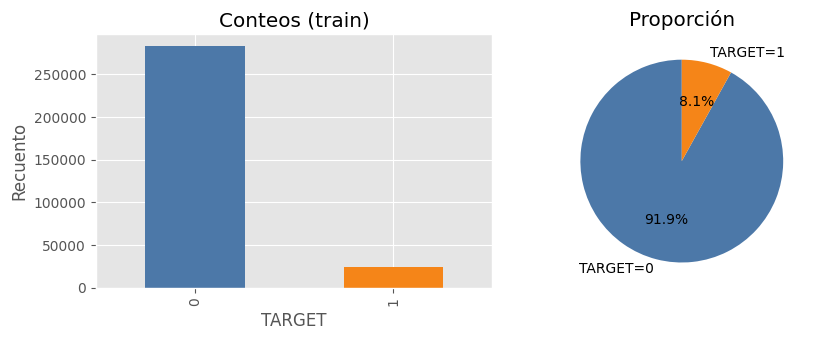

In [3]:
vc = train[y_col].value_counts().sort_index()
n0, n1 = int(vc.get(0, 0)), int(vc.get(1, 0))
imbalance = n1 / len(train) if len(train) else 0
ratio_neg_pos = n0 / n1 if n1 else np.nan

print("Distribución TARGET:", vc.to_string())
print(f"Proporción positivos (TARGET=1): {imbalance:.4f}")
print(f"Ratio clases 0:1 (aprox.): {ratio_neg_pos:.2f}:1")
print("Baseline siempre 0: accuracy ~", f"{1 - imbalance:.4f}", "(mayoría); P/R clase 1 = 0")
print("Baseline siempre 1: accuracy ~", f"{imbalance:.4f}", "| recall 1 = 1 | precision ~", f"{imbalance:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
vc.plot(kind="bar", ax=axes[0], color=["#4c78a8", "#f58518"])
axes[0].set_xlabel("TARGET")
axes[0].set_ylabel("Recuento")
axes[0].set_title("Conteos (train)")
axes[1].pie(
    [n0, n1],
    labels=["TARGET=0", "TARGET=1"],
    autopct="%1.1f%%",
    colors=["#4c78a8", "#f58518"],
    startangle=90,
)
axes[1].set_title("Proporción")
plt.tight_layout()


### Tipos y columnas

Dtypes, cardinalidad `object`, flags binarios, columnas casi constantes.


### Documentación — Tipos de datos y cardinalidad

- **`dtypes`**: conteo de tipos por columna en train.
- **`feat_cols`**: todas las columnas excepto `TARGET`.
- **`num_feats` / `obj_cols`**: separación numéricas vs texto (categóricas crudas).
- **Binarias**: columnas numéricas que solo toman 0 y 1 (flags).
- **`card`**: cardinalidad de columnas `object` (orden descendente).
- **Constantes**: columnas con un único valor (poca información marginal).


In [4]:
dtypes_train = train.dtypes.value_counts()
print("Dtypes en train:")
print(dtypes_train)

feat_cols = [c for c in train.columns if c != y_col]
num_feats = train[feat_cols].select_dtypes(include=[np.number]).columns.tolist()
obj_cols = train[feat_cols].select_dtypes(include=["object"]).columns.tolist()

print("Numéricas:", len(num_feats), "| Object:", len(obj_cols))

binary_like = []
for c in num_feats:
    u = train[c].dropna().unique()
    if len(u) <= 2:
        ufloat = {float(x) for x in u}
        if ufloat <= {0.0, 1.0}:
            binary_like.append(c)
print("Columnas numéricas binarias (solo 0/1):", len(binary_like))

card = train[obj_cols].nunique(dropna=False).sort_values(ascending=False)
print("Top 15 por cardinalidad (object):")
print(card.head(15))

nunique_all = train[feat_cols].nunique(dropna=False)
constant_cols = nunique_all[nunique_all <= 1].index.tolist()
print("Columnas con <=1 valor distinto:", len(constant_cols), constant_cols[:15])


Dtypes en train:
float64    65
int64      41
str        16
Name: count, dtype: int64
Numéricas: 105 | Object: 16


C:\Users\User\AppData\Local\Temp\ipykernel_10584\1177422701.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = train[feat_cols].select_dtypes(include=["object"]).columns.tolist()


Columnas numéricas binarias (solo 0/1): 32
Top 15 por cardinalidad (object):
ORGANIZATION_TYPE             58
OCCUPATION_TYPE               19
NAME_INCOME_TYPE               8
NAME_TYPE_SUITE                8
WALLSMATERIAL_MODE             8
WEEKDAY_APPR_PROCESS_START     7
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
NAME_EDUCATION_TYPE            5
FONDKAPREMONT_MODE             5
HOUSETYPE_MODE                 4
CODE_GENDER                    3
EMERGENCYSTATE_MODE            3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
dtype: int64
Columnas con <=1 valor distinto: 0 []


### Interpretación de resultados — Sección 2

- Una proporción baja de `TARGET=1` confirma desbalance de clases; esto condiciona métricas, umbral y estrategia de validación.
- Muchas variables categóricas de alta cardinalidad o columnas casi constantes anticipan trabajo de encoding/selección.
- Si aparecen muchas flags binarias y bloques con poca variabilidad, modelos lineales requerirán regularización y árboles pueden aprovechar interacciones no lineales.

<a id="sec-3"></a>
## 3. Valores faltantes


Fracción de NA global y comparación **TARGET=0 vs TARGET=1** en las columnas con más nulos.


### Documentación — Valores faltantes

- **`missing_summary`**: fracción de `NA` por columna (todo el train).
- **Visualización**: barras horizontales de las 25 columnas con más nulos.
- **Bloque siguiente**: para las 30 columnas con más nulos, compara la **tasa de NA** entre filas con `TARGET=0` y `TARGET=1`; si difiere, el patrón de missing puede ser informativo (MNAR / necesidad de indicadores).


Columnas con al menos un nulo: 67 / 122


,frac_na
COMMONAREA_AVG,0.698723
COMMONAREA_MODE,0.698723
COMMONAREA_MEDI,0.698723
NONLIVINGAPARTMENTS_MEDI,0.694330
NONLIVINGAPARTMENTS_MODE,0.694330
NONLIVINGAPARTMENTS_AVG,0.694330
FONDKAPREMONT_MODE,0.683862
LIVINGAPARTMENTS_AVG,0.683550
LIVINGAPARTMENTS_MEDI,0.683550
LIVINGAPARTMENTS_MODE,0.683550


Top 15 columnas donde la tasa de NA difiere más entre TARGET 0 y 1:


,column,na_rate_t0,na_rate_t1,diff
27,ELEVATORS_AVG,0.527002,0.600806,0.073804
29,ELEVATORS_MODE,0.527002,0.600806,0.073804
28,ELEVATORS_MEDI,0.527002,0.600806,0.073804
25,NONLIVINGAREA_AVG,0.546019,0.617523,0.071503
24,NONLIVINGAREA_MODE,0.546019,0.617523,0.071503
26,NONLIVINGAREA_MEDI,0.546019,0.617523,0.071503
21,BASEMENTAREA_MEDI,0.579813,0.646042,0.066229
20,BASEMENTAREA_MODE,0.579813,0.646042,0.066229
22,BASEMENTAREA_AVG,0.579813,0.646042,0.066229
17,LANDAREA_MEDI,0.588943,0.648701,0.059758


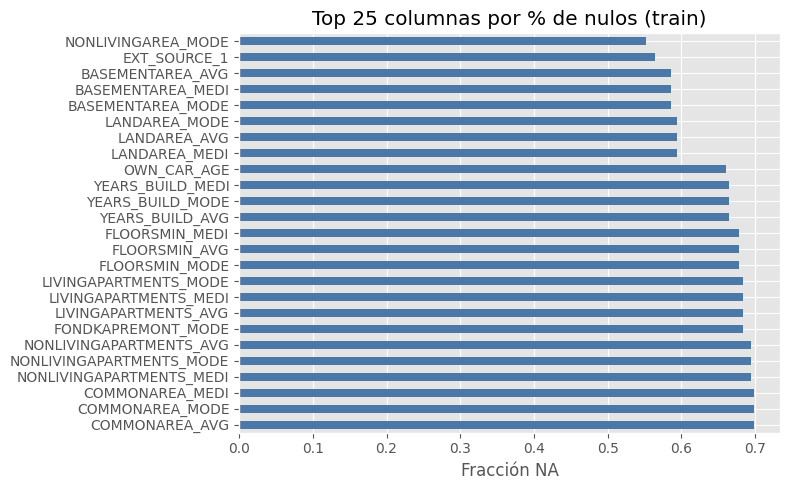

In [5]:
miss = missing_summary(train).sort_values(ascending=False)
miss_nonzero = miss[miss > 0]
print(f"Columnas con al menos un nulo: {len(miss_nonzero)} / {len(train.columns)}")
display(miss_nonzero.head(25).to_frame("frac_na"))

fig, ax = plt.subplots(figsize=(8, 5))
miss_nonzero.head(25).plot(kind="barh", ax=ax, legend=False, color="#4c78a8")
ax.set_xlabel("Fracción NA")
ax.set_title("Top 25 columnas por % de nulos (train)")
plt.tight_layout()

cols_miss = miss_nonzero.head(30).index.tolist()
rows = []
for col in cols_miss:
    if col == y_col:
        continue
    m0 = train.loc[train[y_col] == 0, col].isna().mean()
    m1 = train.loc[train[y_col] == 1, col].isna().mean()
    rows.append({"column": col, "na_rate_t0": m0, "na_rate_t1": m1, "diff": abs(m1 - m0)})
miss_target = pd.DataFrame(rows).sort_values("diff", ascending=False)
print("Top 15 columnas donde la tasa de NA difiere más entre TARGET 0 y 1:")
display(miss_target.head(15))


### Interpretación de resultados — Sección 3

- Columnas con alto `%NA` son candidatas a imputación robusta o estrategias `NaN-friendly`.
- Si la tasa de nulos difiere entre `TARGET=0` y `TARGET=1`, el missing puede contener señal predictiva (crear indicadores de missing suele ayudar).
- Nulos masivos en variables críticas elevan riesgo de inestabilidad y deben monitorearse en producción.

<a id="sec-4"></a>
## 4. Calidad: duplicados e IDs


`SK_ID_CURR` único en train y en test; sin solapamiento train∩test.


### Documentación — Duplicados e IDs

- **`duplicated()`** sobre `SK_ID_CURR`: debe ser 0 en train y test (un registro por solicitud).
- **Intersección de sets** train vs test: no debe haber IDs compartidos entre archivos (simula el holdout de la competición).


In [6]:
dup_train = train[k_curr].duplicated().sum()
dup_test = test[k_curr].duplicated().sum()
overlap = set(train[k_curr]) & set(test[k_curr])

print(f"Filas duplicadas por {k_curr} en train: {dup_train}")
print(f"Filas duplicadas por {k_curr} en test: {dup_test}")
print(f"IDs compartidos train∩test: {len(overlap)}")


Filas duplicadas por SK_ID_CURR en train: 0
Filas duplicadas por SK_ID_CURR en test: 0
IDs compartidos train∩test: 0


### Alineación train / test

Columnas exclusivas de cada tabla y dtypes en el cruce común (sin `TARGET`).


### Documentación — Alineación de columnas train / test

- **Conjuntos de nombres**: columnas solo en train (p. ej. `TARGET`), solo en test, y comunes.
- **Dtypes**: lista columnas comunes donde `train` y `test` declaran tipos distintos (riesgo al concatenar o al aplicar el mismo pipeline).


In [7]:
only_train = set(train.columns) - set(test.columns)
only_test = set(test.columns) - set(train.columns)
common = (set(train.columns) & set(test.columns)) - {y_col}

print("Solo en train:", only_train)
print("Solo en test:", only_test)
print(f"Columnas comunes (sin TARGET): {len(common)}")

dtype_mismatch = []
for col in sorted(common):
    if train[col].dtype != test[col].dtype:
        dtype_mismatch.append((col, train[col].dtype, test[col].dtype))
print(f"Diferencias de dtype en comunes: {len(dtype_mismatch)}")
if dtype_mismatch:
    display(pd.DataFrame(dtype_mismatch, columns=["column", "dtype_train", "dtype_test"]).head(25))


Solo en train: {'TARGET'}
Solo en test: set()
Columnas comunes (sin TARGET): 121
Diferencias de dtype en comunes: 0


### Coherencia train vs test (exploratorio)

Medias en numéricas comunes y test **Kolmogorov-Smirnov** (muestra hasta 50k filas por serie). *p* bajo sugiere distribuciones distintas.


### Documentación — Coherencia de distribuciones (train vs test)

- **`num_common`**: columnas numéricas presentes en ambos conjuntos.
- **Medias**: comparación rápida de `mean_train` vs `mean_test` y diferencia relativa.
- **Kolmogorov–Smirnov (`ks_2samp`)**: contrasta si dos muestras vienen de la misma distribución; aquí se submuestrea hasta 50k filas por lado si hace falta por coste.
- **Interpretación**: p-valores muy bajos o estadísticos KS altos sugieren **deriva** entre train y test en esa variable.


In [8]:
num_common = [
    col
    for col in common
    if col in train.columns
    and pd.api.types.is_numeric_dtype(train[col])
    and pd.api.types.is_numeric_dtype(test[col])
]
rows = []
for col in num_common:
    t_mean = train[col].mean()
    s_mean = test[col].mean()
    diff_rel = abs(t_mean - s_mean) / (abs(t_mean) + 1e-12)
    sub_t = train[col].dropna()
    sub_s = test[col].dropna()
    if len(sub_t) > 50000:
        sub_t = sub_t.sample(50000, random_state=42)
    if len(sub_s) > 50000:
        sub_s = sub_s.sample(50000, random_state=42)
    if len(sub_t) < 2 or len(sub_s) < 2:
        continue
    ks_stat, ks_p = ks_2samp(sub_t, sub_s)
    rows.append(
        {
            "column": col,
            "mean_train": t_mean,
            "mean_test": s_mean,
            "rel_mean_diff": diff_rel,
            "ks_statistic": ks_stat,
            "ks_pvalue": ks_p,
        }
    )
drift = pd.DataFrame(rows).sort_values("ks_statistic", ascending=False)
print("Top 15 por estadístico KS:")
display(drift.head(15))
print("Top 10 por divergencia relativa de medias:")
display(drift.sort_values("rel_mean_diff", ascending=False).head(10)[["column", "mean_train", "mean_test", "rel_mean_diff"]])


Top 15 por estadístico KS:


,column,mean_train,mean_test,rel_mean_diff,ks_statistic,ks_pvalue
87,AMT_REQ_CREDIT_BUREAU_QRT,0.265474,0.546902,1.060097,0.258722,0.000000e+00
103,AMT_REQ_CREDIT_BUREAU_MON,0.267395,0.009299,0.965226,0.155749,0.000000e+00
32,AMT_GOODS_PRICE,538396.207429,462618.840473,0.140746,0.113884,2.595168e-279
37,AMT_CREDIT,599025.999706,516740.435561,0.137366,0.113883,2.628229e-279
30,FLAG_EMAIL,0.056720,0.162646,1.867523,0.106306,2.431487e-243
83,FLAG_DOCUMENT_3,0.710023,0.786620,0.107879,0.075640,2.921517e-123
55,DAYS_LAST_PHONE_CHANGE,-962.858788,-1077.766228,0.119340,0.070076,7.775025e-106
69,AMT_INCOME_TOTAL,168797.919297,178431.805855,0.057073,0.057311,6.558273e-71
1,DAYS_ID_PUBLISH,-2994.202373,-3051.712949,0.019207,0.055992,1.060918e-67
15,AMT_ANNUITY,27108.573909,29426.240209,0.085496,0.054680,1.444485e-64


Top 10 por divergencia relativa de medias:


,column,mean_train,mean_test,rel_mean_diff
30,FLAG_EMAIL,0.056720,0.162646,1.867523
87,AMT_REQ_CREDIT_BUREAU_QRT,0.265474,0.546902,1.060097
47,FLAG_DOCUMENT_16,0.009928,0.000000,1.000000
97,FLAG_DOCUMENT_13,0.003525,0.000000,1.000000
44,FLAG_DOCUMENT_14,0.002936,0.000000,1.000000
27,FLAG_DOCUMENT_15,0.001210,0.000000,1.000000
77,FLAG_DOCUMENT_19,0.000595,0.000000,1.000000
10,FLAG_DOCUMENT_20,0.000507,0.000000,1.000000
28,FLAG_DOCUMENT_21,0.000335,0.000000,1.000000
2,FLAG_DOCUMENT_17,0.000267,0.000000,1.000000


### Documentación — Drift avanzado (PSI + adversarial validation)

- **PSI (Population Stability Index)**: cuantifica el desplazamiento de distribución entre `train` y `test` por variable numérica.
- Regla orientativa: `<0.1` bajo, `0.1-0.25` moderado, `>=0.25` alto.
- **Adversarial validation**: entrenar un clasificador para distinguir filas de `train` vs `test`.
- Si el AUC adversarial es alto, existe deriva multivariada real que puede afectar generalización/calibración.

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


def psi_quantile(train_s: pd.Series, test_s: pd.Series, bins: int = 10, eps: float = 1e-6) -> float:
    """PSI con bins por cuantiles de train para comparar estabilidad train->test."""
    a = train_s.dropna().astype(float)
    b = test_s.dropna().astype(float)
    if len(a) < bins * 20 or len(b) < bins * 20:
        return np.nan
    try:
        q = np.linspace(0, 1, bins + 1)
        edges = np.unique(np.quantile(a, q))
        if len(edges) < 3:
            return np.nan
        a_bins = pd.cut(a, bins=edges, include_lowest=True)
        b_bins = pd.cut(b, bins=edges, include_lowest=True)
        pa = a_bins.value_counts(normalize=True, sort=False).to_numpy()
        pb = b_bins.value_counts(normalize=True, sort=False).to_numpy()
        pa = np.clip(pa, eps, None)
        pb = np.clip(pb, eps, None)
        return float(np.sum((pb - pa) * np.log(pb / pa)))
    except Exception:
        return np.nan


if "drift" in globals() and not drift.empty:
    top_num_for_psi = drift["column"].head(40).tolist()
else:
    top_num_for_psi = num_common[:40] if "num_common" in globals() else []

psi_rows = []
for col in top_num_for_psi:
    if col not in train.columns or col not in test.columns:
        continue
    val = psi_quantile(train[col], test[col], bins=10)
    if pd.isna(val):
        continue
    if val < 0.10:
        band = "bajo"
    elif val < 0.25:
        band = "moderado"
    else:
        band = "alto"
    psi_rows.append({"column": col, "psi": val, "psi_band": band})

psi_df = pd.DataFrame(psi_rows).sort_values("psi", ascending=False) if psi_rows else pd.DataFrame(columns=["column", "psi", "psi_band"])
print("Top 15 variables por PSI (train vs test):")
display(psi_df.head(15))

# Adversarial validation: si AUC >> 0.5, train y test son distinguibles.
adv_num = [c for c in num_common if train[c].notna().mean() > 0.6 and test[c].notna().mean() > 0.6][:40]
adv_cat = [c for c in common if c in train.columns and train[c].dtype == "object"][:20]
adv_cols = adv_num + adv_cat

if not adv_cols:
    print("Adversarial validation omitida: no hay columnas comunes válidas.")
else:
    adv_train = train[adv_cols].copy()
    adv_test = test[adv_cols].copy()
    adv_train["is_test"] = 0
    adv_test["is_test"] = 1

    adv = pd.concat([adv_train, adv_test], axis=0, ignore_index=True)

    # Submuestra balanceada para controlar costo.
    n_each = min(80000, (adv["is_test"] == 0).sum(), (adv["is_test"] == 1).sum())
    idx0 = adv.index[adv["is_test"] == 0]
    idx1 = adv.index[adv["is_test"] == 1]
    pick0 = np.random.choice(idx0, size=int(n_each), replace=False)
    pick1 = np.random.choice(idx1, size=int(n_each), replace=False)
    use_idx = np.concatenate([pick0, pick1])

    adv_sub = adv.loc[use_idx].sample(frac=1.0, random_state=42).reset_index(drop=True)
    X_adv = adv_sub[adv_cols]
    y_adv = adv_sub["is_test"].astype(int)

    num_part = [c for c in adv_cols if c in adv_num]
    cat_part = [c for c in adv_cols if c in adv_cat]

    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_part),
            (
                "cat",
                Pipeline(
                    [
                        ("imp", SimpleImputer(strategy="most_frequent")),
                        ("ohe", OneHotEncoder(handle_unknown="ignore")),
                    ]
                ),
                cat_part,
            ),
        ],
        remainder="drop",
    )

    adv_model = Pipeline(
        steps=[
            ("pre", pre),
            ("clf", LogisticRegression(max_iter=300, solver="liblinear", random_state=42)),
        ]
    )

    xtr, xva, ytr, yva = train_test_split(X_adv, y_adv, test_size=0.25, stratify=y_adv, random_state=42)
    adv_model.fit(xtr, ytr)
    pva = adv_model.predict_proba(xva)[:, 1]
    auc_adv = roc_auc_score(yva, pva)

    print(f"Adversarial AUC (holdout): {auc_adv:.4f}")
    if auc_adv < 0.58:
        print("Interpretación: deriva multivariada baja/moderada.")
    elif auc_adv < 0.65:
        print("Interpretación: deriva multivariada moderada; revisar variables con mayor PSI.")
    else:
        print("Interpretación: deriva multivariada alta; robustecer validación y calibración.")

Top 15 variables por PSI (train vs test):


,column,psi,psi_band
1,AMT_REQ_CREDIT_BUREAU_MON,0.159876,moderado
2,AMT_GOODS_PRICE,0.083040,bajo
3,AMT_CREDIT,0.069183,bajo
6,DAYS_ID_PUBLISH,0.067059,bajo
4,DAYS_LAST_PHONE_CHANGE,0.051813,bajo
7,AMT_ANNUITY,0.032594,bajo
5,AMT_INCOME_TOTAL,0.020051,bajo
10,OWN_CAR_AGE,0.016712,bajo
18,EXT_SOURCE_2,0.009977,bajo
8,AMT_REQ_CREDIT_BUREAU_YEAR,0.007332,bajo


Adversarial AUC (holdout): 0.6703
Interpretación: deriva multivariada alta; robustecer validación y calibración.


### Interpretación de resultados — Sección 4

- Duplicados en `SK_ID_CURR` o solapamiento train-test implican fuga o defectos de partición y deben resolverse antes de modelar.
- Diferencias de dtype en columnas comunes anticipan errores sutiles de pipeline.
- KS/PSI altos y AUC adversarial elevado indican deriva real entre train y test: en ese caso, conviene reforzar validación, calibración y análisis de robustez por segmentos.

<a id="sec-5"></a>
## 5. Otras tablas (volumen)


Filas por CSV auxiliar (comportamiento = múltiples filas por cliente).


### Documentación — Volumetría de tablas auxiliares

- **`count_csv_rows`**: cuenta líneas sin cargar el CSV completo en memoria (solo lectura byte a byte).
- **Uso**: dimensionar el trabajo de joins y agregaciones en `bureau`, balances, cuotas, etc.


In [10]:
def count_csv_rows(path: Path) -> int:
    with path.open("rb") as f:
        return sum(1 for _ in f) - 1


aux_keys = [
    "bureau",
    "bureau_balance",
    "previous_application",
    "pos_cash_balance",
    "installments_payments",
    "credit_card_balance",
]
rows = {}
for k in aux_keys:
    rows[k] = count_csv_rows(table_path(k))

pd.Series(rows, name="n_rows").sort_values(ascending=False)


bureau_balance           27299925
installments_payments    13605401
pos_cash_balance         10001358
credit_card_balance       3840312
bureau                    1716428
previous_application      1670214
Name: n_rows, dtype: int64

### Interpretación de resultados — Sección 5

- Tablas auxiliares con gran volumetría implican que la señal histórica está distribuida en múltiples eventos por cliente.
- El diseño de agregaciones temporales y por granularidad será determinante para capturar valor sin leakage.
- Esta lectura sirve también para estimar costo de cómputo y estrategia de particionado de joins.

<a id="sec-6"></a>
## 6. Rangos plausibles (sanity checks)


`basic_range_checks` + percentiles de `DAYS_BIRTH`. Rango `DAYS_BIRTH` ampliado a (-30000, 0).


### Documentación — Sanity checks de rangos

- **`range_hints`**: intervalos plausibles para scores externos (`EXT_SOURCE_*`), días (`DAYS_BIRTH`, `DAYS_EMPLOYED` con placeholder 365243).
- **`basic_range_checks`**: comprueba que valores no nulos caen en el rango (o marca REVISAR).
- **Percentiles de `DAYS_BIRTH`**: contexto si el check rígido falla por valores límite.


In [11]:
range_hints = {
    "EXT_SOURCE_1": (0.0, 1.0),
    "EXT_SOURCE_2": (0.0, 1.0),
    "EXT_SOURCE_3": (0.0, 1.0),
    "DAYS_BIRTH": (-30000, 0),
    "DAYS_EMPLOYED": (-25000, 365243),
}

present = {k: v for k, v in range_hints.items() if k in train.columns}
chk = basic_range_checks(train, present)
for col, ok in sorted(chk.items()):
    print(f"{col}: {'OK' if ok else 'REVISAR'}")

if "DAYS_BIRTH" in train.columns:
    db = train["DAYS_BIRTH"].dropna()
    print("DAYS_BIRTH min/max/p01/p99:", float(db.min()), float(db.max()), float(db.quantile(0.01)), float(db.quantile(0.99)))

if "DAYS_EMPLOYED" in train.columns:
    special = (train["DAYS_EMPLOYED"] == 365243).mean()
    print(f"Fracción DAYS_EMPLOYED == 365243 (placeholder): {special:.4f}")


DAYS_BIRTH: OK
DAYS_EMPLOYED: OK
EXT_SOURCE_1: OK
EXT_SOURCE_2: OK
EXT_SOURCE_3: OK
DAYS_BIRTH min/max/p01/p99: -25229.0 -7489.0 -24419.0 -8263.0
Fracción DAYS_EMPLOYED == 365243 (placeholder): 0.1801


### Interpretación de resultados — Sección 6

- Variables fuera de rangos plausibles pueden reflejar placeholders, errores de captura o codificaciones especiales.
- Si `DAYS_EMPLOYED=365243` aparece con frecuencia, debe tratarse explícitamente como valor especial antes de entrenar.
- Estos checks reducen riesgo de que outliers espurios dominen métricas o sesguen calibración.

<a id="sec-7"></a>
## 7. Asociación con `TARGET`


Pearson en numéricas; heatmap entre top correlaciones; **Cramér V** y chi² en `object`; tasas de default por grupo.


### Documentación — Asociación con `TARGET` (numéricas y categóricas)

- **Pearson**: correlación lineal de cada numérica con `TARGET`; ordena por valor absoluto.
- **Heatmap**: matriz de correlación entre las **top 25** variables por |corr| con `TARGET` más la propia `TARGET` (dependencias lineales entre candidatos a feature).
- **Cramér V**: a partir de `chi2_contingency` sobre tablas cruzadas categoría × `TARGET`; mide asociación 0–1 en categóricas.
- **Tablas por grupo**: tasa de default (`mean` de `TARGET`) y volumen `n` para variables de negocio (`CODE_GENDER`, etc.).


Top 15 correlación con TARGET (Pearson):


,corr_with_TARGET
EXT_SOURCE_3,-0.178919
EXT_SOURCE_2,-0.160472
EXT_SOURCE_1,-0.155317
DAYS_BIRTH,0.078239
REGION_RATING_CLIENT_W_CITY,0.060893
REGION_RATING_CLIENT,0.058899
DAYS_LAST_PHONE_CHANGE,0.055218
DAYS_ID_PUBLISH,0.051457
REG_CITY_NOT_WORK_CITY,0.050994
FLAG_EMP_PHONE,0.045982


Bottom 5 (menor |corr|):


,corr_with_TARGET
FLAG_DOCUMENT_12,-0.000756
FLAG_MOBIL,0.000534
FLAG_CONT_MOBILE,0.000370
FLAG_DOCUMENT_5,-0.000316
FLAG_DOCUMENT_20,0.000215


Asociación categórica vs TARGET (Cramér V):


...

,default_rate,n
CODE_GENDER,,
F,0.069993,202448
M,0.101419,105059
XNA,0.000000,4


Tasa de default por NAME_INCOME_TYPE


,default_rate,n
NAME_INCOME_TYPE,,
Working,0.095885,158774
Commercial associate,0.074843,71617
Pensioner,0.053864,55362
State servant,0.057550,21703
Unemployed,0.363636,22
Student,0.000000,18
Businessman,0.000000,10
Maternity leave,0.400000,5


Tasa de default por FLAG_OWN_CAR


,default_rate,n
FLAG_OWN_CAR,,
N,0.085002,202924
Y,0.072437,104587


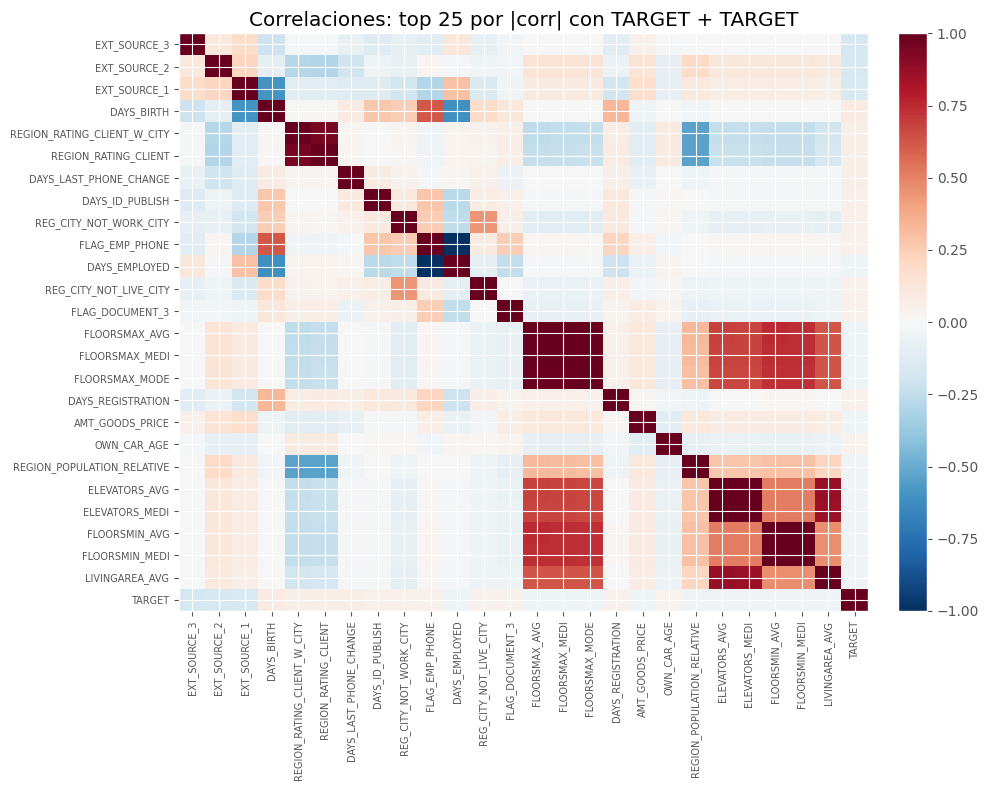

In [12]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
if y_col in num_cols:
    num_cols.remove(y_col)

corr = train[num_cols + [y_col]].corr(numeric_only=True)[y_col].drop(labels=[y_col], errors="ignore")
corr = corr.replace([np.inf, -np.inf], np.nan).dropna()
corr_sorted = corr.reindex(corr.abs().sort_values(ascending=False).index)

print("Top 15 correlación con TARGET (Pearson):")
display(corr_sorted.head(15).to_frame("corr_with_TARGET"))
print("Bottom 5 (menor |corr|):")
display(corr_sorted.tail(5).to_frame("corr_with_TARGET"))

top_k = 25
top_for_heatmap = [c for c in corr_sorted.head(top_k).index if c in train.columns]
sub = train[top_for_heatmap + [y_col]].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sub.values, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(sub.columns)))
ax.set_yticks(range(len(sub.columns)))
ax.set_xticklabels(sub.columns, rotation=90, fontsize=7)
ax.set_yticklabels(sub.columns, fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title(f"Correlaciones: top {top_k} por |corr| con TARGET + TARGET")
plt.tight_layout()


def cramers_v(conf: np.ndarray) -> float:
    chi2, _, _, _ = chi2_contingency(conf, correction=False)
    n = conf.sum()
    r, k = conf.shape
    return float(np.sqrt(chi2 / (n * (min(r, k) - 1))))


cat_rows = []
for col in obj_cols:
    tab = pd.crosstab(train[col].fillna("__NA__"), train[y_col])
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        continue
    try:
        chi2, p, _, _ = chi2_contingency(tab.values)
        cv = cramers_v(tab.values.astype(float))
        cat_rows.append({"column": col, "chi2_pvalue": p, "cramers_v": cv})
    except ValueError:
        continue
cat_assoc = pd.DataFrame(cat_rows).sort_values("cramers_v", ascending=False)
print("Asociación categórica vs TARGET (Cramér V):")
display(cat_assoc)

for col in ["CODE_GENDER", "NAME_INCOME_TYPE", "FLAG_OWN_CAR"]:
    if col not in train.columns:
        continue
    t = train.groupby(col, dropna=False)[y_col].agg(["mean", "count"]).rename(columns={"mean": "default_rate", "count": "n"})
    t = t.sort_values("n", ascending=False)
    print("Tasa de default por", col)
    display(t.head(15))


### Distribuciones `EXT_SOURCE_*` por `TARGET`


### Documentación — Histogramas `EXT_SOURCE_*`

- Para cada `EXT_SOURCE` disponible, superpone histogramas por clase (`TARGET` 0 vs 1) en [0, 1].
- **Densidad** (`density=True`): comparar formas aunque los tamaños de clase difieran.


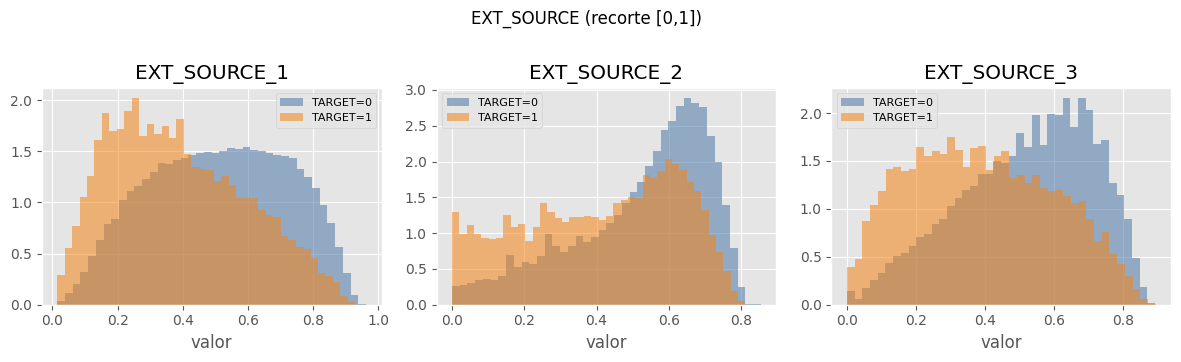

In [13]:
ext_cols = [c for c in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"] if c in train.columns]
if not ext_cols:
    print("No hay EXT_SOURCE en train.")
else:
    fig, axes = plt.subplots(1, len(ext_cols), figsize=(4 * len(ext_cols), 3.5))
    if len(ext_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, ext_cols):
        for tval, label, color in [(0, "TARGET=0", "#4c78a8"), (1, "TARGET=1", "#f58518")]:
            s = train.loc[train[y_col] == tval, col].dropna()
            s = s[(s >= 0) & (s <= 1)]
            ax.hist(s, bins=40, alpha=0.55, label=label, color=color, density=True)
        ax.set_title(col)
        ax.set_xlabel("valor")
        ax.legend(fontsize=8)
    plt.suptitle("EXT_SOURCE (recorte [0,1])", y=1.02)
    plt.tight_layout()


### Tabla `bureau`: filas por cliente

Registros en `bureau.csv` por `SK_ID_CURR` y default por decil (aprox.).


### Documentación — Agregación mínima de `bureau`

- Lee solo **`SK_ID_CURR`** de `bureau.csv` para contar cuántos registros de buró tiene cada cliente.
- **Merge** con train: añade `n_bureau_records` (0 si no hay filas en buró).
- **Deciles** (`qcut`) con `duplicates="drop"` si hay empates: tasa de default por franja de volumen de historial en buró.


In [14]:
bureau_ids = read_table("bureau", usecols=[k_curr])
n_per = bureau_ids.groupby(k_curr).size().rename("n_bureau_records")
train_nb = train[[k_curr, y_col]].merge(n_per, on=k_curr, how="left")
train_nb["n_bureau_records"] = train_nb["n_bureau_records"].fillna(0)

print(train_nb["n_bureau_records"].describe(percentiles=[0.5, 0.9, 0.99]))
print("Tasa de default por decil de n_bureau_records (aprox.):")
train_nb["decile"] = pd.qcut(train_nb["n_bureau_records"], q=10, duplicates="drop")
display(train_nb.groupby("decile", observed=True)[y_col].agg(["mean", "count"]))


count    307511.000000
mean          4.765114
std           4.496199
min           0.000000
50%           4.000000
90%          11.000000
99%          20.000000
max         116.000000
Name: n_bureau_records, dtype: float64
Tasa de default por decil de n_bureau_records (aprox.):


,mean,count
decile,,
"(-0.001, 1.0]",0.094329,80092
"(1.0, 2.0]",0.078125,35635
"(2.0, 3.0]",0.076082,32925
"(3.0, 4.0]",0.071273,28973
"(4.0, 5.0]",0.074445,24985
"(5.0, 6.0]",0.072069,20952
"(6.0, 8.0]",0.073540,31629
"(8.0, 11.0]",0.079264,27238
"(11.0, 116.0]",0.082170,25082


### Interpretación de resultados — Sección 7

- Variables con mayor correlación/MI/Cramér V frente a `TARGET` son candidatas prioritarias para baseline.
- Tasas de default por grupo permiten identificar segmentos de riesgo heterogéneo y posibles reglas de negocio.
- Si `EXT_SOURCE_*` separa bien clases y `n_bureau_records` muestra gradiente de riesgo, son señales de alto valor para ingeniería de features.

<a id="sec-8"></a>
## 8. Auditoría preliminar de leakage (`application_*`)


Revisar nombres y agregaciones temporales en tablas auxiliares en el notebook 02.


### Documentación — Heurística de nombres (leakage)

- Busca subcadenas en mayúsculas (`TARGET`, `DEFAULT`, etc.) en nombres de columnas para revisión manual.
- **`FLAG_DOCUMENT_*`**: cuenta documentos aportados; no implica leakage por sí solo, pero conviene documentar en el informe técnico.


In [15]:
sus = [
    c
    for c in train.columns
    if any(x in c.upper() for x in ("TARGET", "DEFAULT", "FUTURE", "POST"))
]
print("Columnas a revisar por nombre:", [c for c in sus if c != y_col])

doc_flags = [c for c in train.columns if "FLAG_DOCUMENT" in c]
print("FLAG_DOCUMENT_*:", len(doc_flags), "columnas")


Columnas a revisar por nombre: []
FLAG_DOCUMENT_*: 20 columnas


### Documentación — Auditoría reforzada de leakage

- Añadimos una auditoría semántica con diccionario de términos de post-evento (`OVERDUE`, `RECOVERY`, `WRITE_OFF`, etc.).
- Incluimos un **screening univariado**: variables con AUC muy alto para `TARGET` merecen revisión manual por potencial fuga o proxy no permitido.
- Esta celda no sentencia leakage automáticamente; prioriza qué revisar en profundidad en ingeniería de variables.

In [16]:
from sklearn.metrics import roc_auc_score

post_event_tokens = [
    "DEFAULT",
    "OVERDUE",
    "DPD",
    "RECOVERY",
    "WRITE",
    "LOSS",
    "CLOSED",
    "TERMINATION",
    "COLLECTION",
    "LEGAL",
    "LATE",
    "PAST_DUE",
]

sus_semantic = [
    c for c in train.columns if any(tok in c.upper() for tok in post_event_tokens) and c != y_col
]
print("Posibles columnas post-evento por nombre:", sus_semantic[:40], "| total:", len(sus_semantic))

# Screening univariado de señal anómala (AUC alto).
auc_rows = []
num_for_leak = [
    c
    for c in train.select_dtypes(include=[np.number]).columns
    if c != y_col and train[c].notna().mean() > 0.7 and train[c].nunique(dropna=True) > 20
]

for col in num_for_leak:
    x = train[col].fillna(train[col].median())
    y = train[y_col].astype(int)
    try:
        auc = roc_auc_score(y, x)
        auc = max(auc, 1.0 - auc)
    except ValueError:
        continue
    auc_rows.append({"column": col, "auc_univariate": auc})

auc_scan = pd.DataFrame(auc_rows).sort_values("auc_univariate", ascending=False) if auc_rows else pd.DataFrame(columns=["column", "auc_univariate"])
print("Top 15 AUC univariado (mayor señal individual):")
display(auc_scan.head(15))

high_risk_auc = auc_scan[auc_scan["auc_univariate"] >= 0.80].copy()
if len(high_risk_auc):
    print("Variables a revisar manualmente por señal atípicamente alta (AUC >= 0.80):")
    display(high_risk_auc)
else:
    print("No se detectaron variables con AUC univariado >= 0.80 en este screening.")

Posibles columnas post-evento por nombre: [] | total: 0
Top 15 AUC univariado (mayor señal individual):


,column,auc_univariate
11,EXT_SOURCE_2,0.655914
12,EXT_SOURCE_3,0.649330
6,DAYS_BIRTH,0.583003
15,DAYS_LAST_PHONE_CHANGE,0.556864
9,DAYS_ID_PUBLISH,0.555670
8,DAYS_REGISTRATION,0.542568
4,AMT_GOODS_PRICE,0.533333
5,REGION_POPULATION_RELATIVE,0.532374
7,DAYS_EMPLOYED,0.526606
10,HOUR_APPR_PROCESS_START,0.524177


No se detectaron variables con AUC univariado >= 0.80 en este screening.


### Interpretación de resultados — Sección 8

- La heurística por nombre y el screening por AUC no prueban fuga por sí solos, pero priorizan revisión detallada.
- Variables con señal individual extremadamente alta deben auditarse en disponibilidad temporal y causalidad.
- Esta sección funciona como filtro preventivo para evitar contaminación del entrenamiento.

<a id="sec-9"></a>
## 9. Reproducibilidad


Valores de `configs/base.yaml`.


### Documentación — Reproducibilidad del pipeline

- Lee **`configs/base.yaml`** y muestra semilla, fracciones de split y métricas previstas.
- **Uso**: trazabilidad entre este EDA y la validación/modelado en otros notebooks.


In [17]:
base_path = project_root() / "configs" / "base.yaml"
with open(base_path, encoding="utf-8") as f:
    base_cfg = yaml.safe_load(f)

print("seed:", base_cfg.get("seed"))
print("splits:", base_cfg.get("splits"))
print("métricas:", base_cfg.get("metrics"))


seed: 42
splits: {'test_size': 0.2, 'val_size': 0.1, 'stratify': True}
métricas: {'primary': 'roc_auc', 'secondary': ['pr_auc', 'brier_score', 'log_loss']}


### Interpretación de resultados — Sección 9

- Si semilla, splits y métricas config coinciden con lo esperado, el experimento es reproducible.
- Cualquier divergencia aquí explica diferencias de resultados entre corridas y equipos.
- Esta sección aporta trazabilidad técnica para el resto del pipeline.

<a id="sec-10"></a>
## 10. EDA univariado, bivariado y multivariado



### Documentación — EDA univariado

- **Objetivo:** entender la distribución de cada variable por separado (sin condicionar por otras).
- **Qué calculamos aquí:** estadísticos descriptivos para numéricas y frecuencias para categóricas.
- **Por qué importa:** detecta asimetrías, outliers, colas pesadas, categorías raras y variables casi constantes antes de modelar.

In [18]:
# Univariado: resumen de numéricas
num_stats = train[num_feats].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
num_stats["missing_rate"] = train[num_feats].isna().mean()
num_stats["skew"] = train[num_feats].skew(numeric_only=True)
print("Top 15 variables numéricas por missing_rate:")
display(num_stats.sort_values("missing_rate", ascending=False).head(15))

print("Top 15 variables numéricas por |skew| (asimetría):")
display(num_stats.reindex(num_stats["skew"].abs().sort_values(ascending=False).index).head(15))

# Univariado: resumen de categóricas
cat_summary = []
for col in obj_cols:
    vc = train[col].value_counts(dropna=False)
    top_cat = vc.index[0] if len(vc) else None
    top_freq = float(vc.iloc[0] / len(train)) if len(vc) else np.nan
    cat_summary.append(
        {
            "column": col,
            "n_unique": train[col].nunique(dropna=False),
            "missing_rate": train[col].isna().mean(),
            "top_category": top_cat,
            "top_share": top_freq,
        }
    )
cat_summary = pd.DataFrame(cat_summary).sort_values(["n_unique", "missing_rate"], ascending=[False, False])
print("Resumen univariado categóricas (top 15 por cardinalidad):")
display(cat_summary.head(15))

Top 15 variables numéricas por missing_rate:


,count,mean,std,min,1%,5%,50%,95%,99%,max,missing_rate,skew
COMMONAREA_AVG,92646.0,0.044621,0.076036,0.0,0.0000,0.0000,0.0211,0.1601,0.376555,1.0,0.698723,5.457305
COMMONAREA_MEDI,92646.0,0.044595,0.076144,0.0,0.0000,0.0000,0.0208,0.1609,0.378555,1.0,0.698723,5.419238
COMMONAREA_MODE,92646.0,0.042553,0.074445,0.0,0.0000,0.0000,0.0190,0.1532,0.365555,1.0,0.698723,5.620589
NONLIVINGAPARTMENTS_AVG,93997.0,0.008809,0.047732,0.0,0.0000,0.0000,0.0000,0.0309,0.108100,1.0,0.694330,15.541185
NONLIVINGAPARTMENTS_MODE,93997.0,0.008076,0.046276,0.0,0.0000,0.0000,0.0000,0.0272,0.097300,1.0,0.694330,16.251819
NONLIVINGAPARTMENTS_MEDI,93997.0,0.008651,0.047415,0.0,0.0000,0.0000,0.0000,0.0311,0.104800,1.0,0.694330,15.671995
LIVINGAPARTMENTS_AVG,97312.0,0.100775,0.092576,0.0,0.0034,0.0101,0.0756,0.2723,0.453900,1.0,0.683550,3.042198
LIVINGAPARTMENTS_MEDI,97312.0,0.101954,0.093642,0.0,0.0034,0.0103,0.0761,0.2770,0.461700,1.0,0.683550,2.988291
LIVINGAPARTMENTS_MODE,97312.0,0.105645,0.097880,0.0,0.0028,0.0110,0.0771,0.2948,0.488500,1.0,0.683550,2.902672
FLOORSMIN_AVG,98869.0,0.231894,0.161380,0.0,0.0000,0.0417,0.2083,0.5000,0.708300,1.0,0.678486,0.954197


Top 15 variables numéricas por |skew| (asimetría):


,count,mean,std,min,1%,5%,50%,95%,99%,max,missing_rate,skew
FLAG_MOBIL,307511.0,0.999997,0.001803,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000,-554.536744
FLAG_DOCUMENT_12,307511.0,0.000007,0.002550,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,392.114779
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,45000.0,67500.0,147150.0,337500.0,472500.0,117000000.0,0.000000,391.559654
FLAG_DOCUMENT_10,307511.0,0.000023,0.004771,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,209.589054
FLAG_DOCUMENT_2,307511.0,0.000042,0.006502,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,153.791817
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,2.0,2.0,261.0,0.135016,134.365776
FLAG_DOCUMENT_4,307511.0,0.000081,0.009016,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,110.894364
FLAG_DOCUMENT_7,307511.0,0.000192,0.013850,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,72.174108
FLAG_DOCUMENT_17,307511.0,0.000267,0.016327,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,61.214140
FLAG_DOCUMENT_21,307511.0,0.000335,0.018299,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,54.612939


Resumen univariado categóricas (top 15 por cardinalidad):


,column,n_unique,missing_rate,top_category,top_share
11,ORGANIZATION_TYPE,58,0.000000,Business Entity Type 3,0.221104
9,OCCUPATION_TYPE,19,0.313455,NaN,0.313455
14,WALLSMATERIAL_MODE,8,0.508408,NaN,0.508408
4,NAME_TYPE_SUITE,8,0.004201,Unaccompanied,0.808186
5,NAME_INCOME_TYPE,8,0.000000,Working,0.516320
10,WEEKDAY_APPR_PROCESS_START,7,0.000000,TUESDAY,0.175282
7,NAME_FAMILY_STATUS,6,0.000000,Married,0.638780
8,NAME_HOUSING_TYPE,6,0.000000,House / apartment,0.887344
12,FONDKAPREMONT_MODE,5,0.683862,NaN,0.683862
6,NAME_EDUCATION_TYPE,5,0.000000,Secondary / secondary special,0.710189


### Documentación — EDA bivariado

- **Objetivo:** medir relaciones entre pares de variables o variable vs `TARGET`.
- **Qué hacemos:**
  - numérica vs `TARGET` con diferencia de medias estandarizada,
  - categórica vs `TARGET` con tasa de default por categoría,
  - numérica vs numérica con ranking de correlaciones fuertes.
- **Uso:** priorizar features y detectar pares redundantes o altamente acoplados.

In [19]:
# Bivariado: numérica vs TARGET (efecto estandarizado)
rows_eff = []
for col in num_feats:
    x0 = train.loc[train[y_col] == 0, col].dropna()
    x1 = train.loc[train[y_col] == 1, col].dropna()
    if len(x0) < 10 or len(x1) < 10:
        continue
    std_pooled = np.sqrt((x0.var() + x1.var()) / 2)
    if std_pooled == 0 or np.isnan(std_pooled):
        continue
    eff = (x1.mean() - x0.mean()) / std_pooled
    rows_eff.append({"column": col, "cohens_d_1_vs_0": eff, "mean_t0": x0.mean(), "mean_t1": x1.mean()})

bi_num_target = pd.DataFrame(rows_eff).sort_values("cohens_d_1_vs_0", key=lambda s: s.abs(), ascending=False)
print("Top 15 numéricas por |Cohen's d| frente a TARGET:")
display(bi_num_target.head(15))

# Bivariado: categórica vs TARGET (default rate)
cat_target_rows = []
for col in obj_cols:
    grp = train.groupby(col, dropna=False)[y_col].agg(["mean", "count"]).reset_index()
    grp = grp.rename(columns={"mean": "default_rate", "count": "n"})
    # evitar categorías muy pequeñas para estabilidad
    grp_valid = grp[grp["n"] >= 200]
    if grp_valid.empty:
        continue
    spread = grp_valid["default_rate"].max() - grp_valid["default_rate"].min()
    cat_target_rows.append({"column": col, "n_groups_ge_200": len(grp_valid), "default_rate_spread": spread})

bi_cat_target = pd.DataFrame(cat_target_rows).sort_values("default_rate_spread", ascending=False)
print("Categóricas con mayor dispersión de default_rate (grupos n>=200):")
display(bi_cat_target.head(15))

# Bivariado: numérica vs numérica (colinealidad simple)
corr_num = train[num_feats].corr(numeric_only=True).abs()
upper = corr_num.where(np.triu(np.ones(corr_num.shape), k=1).astype(bool))
pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "var1", "level_1": "var2", 0: "abs_corr"})
    .sort_values("abs_corr", ascending=False)
)
print("Top 20 pares numéricos por correlación absoluta:")
display(pairs.head(20))

Top 15 numéricas por |Cohen's d| frente a TARGET:


,column,cohens_d_1_vs_0,mean_t0,mean_t1
30,EXT_SOURCE_3,-0.656891,0.520969,0.390717
28,EXT_SOURCE_1,-0.602066,0.511461,0.386968
29,EXT_SOURCE_2,-0.562319,0.523479,0.410935
7,DAYS_BIRTH,0.292881,-16138.176397,-14884.828077
20,REGION_RATING_CLIENT_W_CITY,0.224327,2.022449,2.134824
19,REGION_RATING_CLIENT,0.217187,2.043578,2.153635
78,DAYS_LAST_PHONE_CHANGE,0.210677,-976.388294,-808.796818
10,DAYS_ID_PUBLISH,0.188596,-3017.219788,-2732.099617
13,FLAG_EMP_PHONE,0.180958,0.814653,0.879517
26,REG_CITY_NOT_WORK_CITY,0.179662,0.224090,0.302920


Categóricas con mayor dispersión de default_rate (grupos n>=200):


,column,n_groups_ge_200,default_rate_spread
9,OCCUPATION_TYPE,19,0.123221
11,ORGANIZATION_TYPE,51,0.119600
8,NAME_HOUSING_TYPE,6,0.057406
6,NAME_EDUCATION_TYPE,4,0.055726
14,WALLSMATERIAL_MODE,8,0.049761
4,NAME_TYPE_SUITE,8,0.044126
5,NAME_INCOME_TYPE,4,0.042021
7,NAME_FAMILY_STATUS,5,0.041204
13,HOUSETYPE_MODE,4,0.031967
1,CODE_GENDER,2,0.031426


Top 20 pares numéricos por correlación absoluta:


,var1,var2,abs_corr
853,DAYS_EMPLOYED,FLAG_EMP_PHONE,0.999755
3632,YEARS_BUILD_AVG,YEARS_BUILD_MEDI,0.998495
7846,OBS_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,0.998490
4162,FLOORSMIN_AVG,FLOORSMIN_MEDI,0.997241
4056,FLOORSMAX_AVG,FLOORSMAX_MEDI,0.997034
3950,ENTRANCES_AVG,ENTRANCES_MEDI,0.996886
3844,ELEVATORS_AVG,ELEVATORS_MEDI,0.996099
3738,COMMONAREA_AVG,COMMONAREA_MEDI,0.995978
4480,LIVINGAREA_AVG,LIVINGAREA_MEDI,0.995596
3314,APARTMENTS_AVG,APARTMENTS_MEDI,0.995081


### Documentación — EDA multivariado

- **Objetivo:** analizar estructuras conjuntas entre varias variables simultáneamente.
- **Qué hacemos:**
  - imputación simple para análisis exploratorio,
  - estandarización,
  - PCA para ver varianza explicada acumulada,
  - visualización de clientes en el plano PC1–PC2 coloreado por `TARGET`.
- **Interpretación:** no es modelo final; sirve para detectar separabilidad parcial, redundancia y complejidad intrínseca de la señal.

Varianza explicada por PCA (primeras componentes):


,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.175987,0.175987
1,2,0.046504,0.222491
2,3,0.039667,0.262157
3,4,0.033241,0.295398
4,5,0.030215,0.325613
5,6,0.027904,0.353517
6,7,0.024684,0.378201
7,8,0.023993,0.402194
8,9,0.023615,0.425809
9,10,0.022045,0.447854


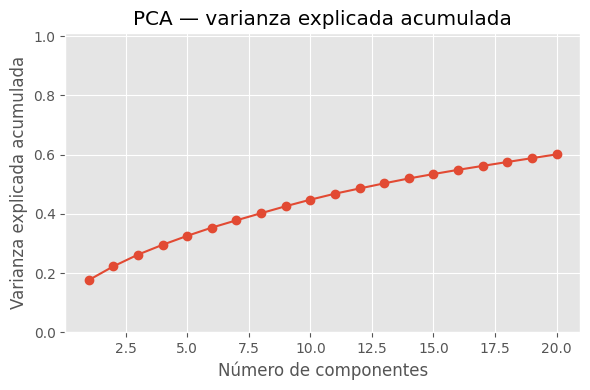

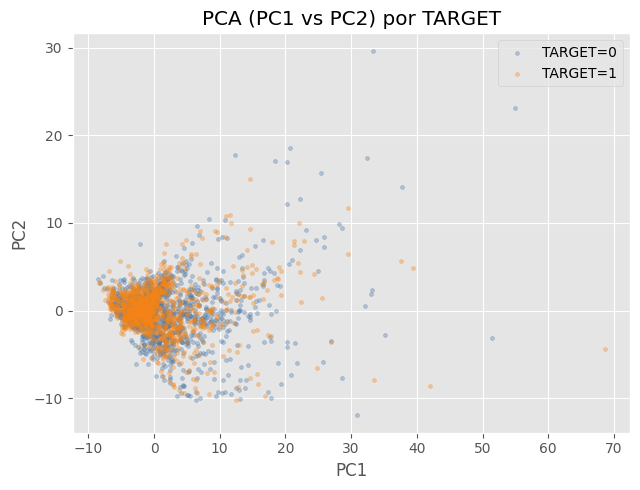

In [20]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Multivariado: PCA sobre numéricas (sin TARGET)
num_for_pca = [c for c in num_feats if train[c].notna().sum() > 1000]
X = train[num_for_pca].copy()

# Imputación robusta para exploración (mediana)
X = X.fillna(X.median(numeric_only=True))

# Submuestra para costo controlado
if len(X) > 80000:
    idx = X.sample(80000, random_state=42).index
    Xs = X.loc[idx]
    ys = train.loc[idx, y_col]
else:
    Xs = X
    ys = train[y_col]

scaler = StandardScaler()
Xs_scaled = scaler.fit_transform(Xs)

pca = PCA(n_components=min(20, Xs_scaled.shape[1]), random_state=42)
pcs = pca.fit_transform(Xs_scaled)
expl = pca.explained_variance_ratio_
cum_expl = np.cumsum(expl)

pca_table = pd.DataFrame({
    "component": np.arange(1, len(expl) + 1),
    "explained_variance_ratio": expl,
    "cumulative_explained_variance": cum_expl,
})
print("Varianza explicada por PCA (primeras componentes):")
display(pca_table.head(15))

# Gráfico acumulado
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(pca_table["component"], pca_table["cumulative_explained_variance"], marker="o")
ax.set_xlabel("Número de componentes")
ax.set_ylabel("Varianza explicada acumulada")
ax.set_title("PCA — varianza explicada acumulada")
ax.set_ylim(0, 1.01)
plt.tight_layout()

# Plano PC1-PC2 con muestra balanceada para visual
pc_df = pd.DataFrame({"PC1": pcs[:, 0], "PC2": pcs[:, 1], "TARGET": ys.values})
plot_df = pd.concat([
    pc_df[pc_df["TARGET"] == 0].sample(min(3000, (pc_df["TARGET"] == 0).sum()), random_state=42),
    pc_df[pc_df["TARGET"] == 1].sample(min(3000, (pc_df["TARGET"] == 1).sum()), random_state=42),
])

fig, ax = plt.subplots(figsize=(6.5, 5))
for tval, color, label in [(0, "#4c78a8", "TARGET=0"), (1, "#f58518", "TARGET=1")]:
    ss = plot_df[plot_df["TARGET"] == tval]
    ax.scatter(ss["PC1"], ss["PC2"], s=8, alpha=0.35, c=color, label=label)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA (PC1 vs PC2) por TARGET")
ax.legend()
plt.tight_layout()

### Interpretación de resultados — Sección 10

- Univariado: distribuciones sesgadas, outliers y missing alto orientan transformaciones e imputación.
- Bivariado: tamaños de efecto y correlaciones ayudan a priorizar variables y detectar redundancia.
- Multivariado (PCA): si la varianza se concentra en pocas componentes hay estructura compacta; si no, el problema requiere modelos más flexibles.

<a id="sec-11"></a>
## 11. EDA premium (estadística avanzada)


Esta sección profundiza en evidencia estadística y estructura global del dataset: tests no paramétricos, información mutua, colinealidad (VIF) y proyecciones no lineales.

### Documentación — Univariado premium (numéricas vs TARGET)

- Usamos **Mann-Whitney U** por variable numérica para contrastar si la distribución en `TARGET=1` difiere de `TARGET=0` sin asumir normalidad.
- Reportamos `p_value` y `-log10(p)` para ranking.
- Añadimos **q-value aproximado (Benjamini-Hochberg)** para controlar falsos positivos por múltiples pruebas.

In [21]:
from scipy.stats import mannwhitneyu

mw_rows = []
for col in num_feats:
    x0 = train.loc[train[y_col] == 0, col].dropna()
    x1 = train.loc[train[y_col] == 1, col].dropna()
    if len(x0) < 30 or len(x1) < 30:
        continue
    try:
        stat, p = mannwhitneyu(x1, x0, alternative="two-sided")
    except ValueError:
        continue
    mw_rows.append({"column": col, "u_stat": stat, "p_value": p})

mw = pd.DataFrame(mw_rows)
if not mw.empty:
    mw = mw.sort_values("p_value", ascending=True).reset_index(drop=True)
    # Benjamini-Hochberg q-value aproximado
    m = len(mw)
    mw["rank"] = np.arange(1, m + 1)
    mw["q_bh"] = (mw["p_value"] * m / mw["rank"]).clip(upper=1.0)
    mw["minus_log10_p"] = -np.log10(mw["p_value"].clip(lower=1e-300))
    print("Top 20 variables numéricas por evidencia de diferencia de distribución (Mann-Whitney):")
    display(mw.head(20))
else:
    print("No se pudieron calcular pruebas Mann-Whitney con el mínimo de muestras definido.")

Top 20 variables numéricas por evidencia de diferencia de distribución (Mann-Whitney):


,column,u_stat,p_value,rank,q_bh,minus_log10_p
0,DAYS_BIRTH,4.091325e+09,0.000000e+00,1,0.000000e+00,300.000000
1,EXT_SOURCE_2,2.403004e+09,0.000000e+00,2,0.000000e+00,300.000000
2,EXT_SOURCE_1,4.170598e+08,0.000000e+00,3,0.000000e+00,300.000000
3,EXT_SOURCE_3,1.395963e+09,0.000000e+00,4,0.000000e+00,300.000000
4,REGION_RATING_CLIENT_W_CITY,3.853983e+09,2.679860e-250,5,5.627707e-249,249.571888
5,REGION_RATING_CLIENT,3.846132e+09,4.555792e-234,6,7.972635e-233,233.341436
6,DAYS_LAST_PHONE_CHANGE,3.907877e+09,6.194142e-195,7,9.291212e-194,194.208019
7,DAYS_ID_PUBLISH,3.899514e+09,1.391775e-186,8,1.826704e-185,185.856431
8,REG_CITY_NOT_WORK_CITY,3.785445e+09,6.397468e-176,9,7.463712e-175,175.193992
9,FLAG_EMP_PHONE,3.736436e+09,2.033172e-143,10,2.134830e-142,142.691826


### Documentación — Bivariado premium (señal predictiva y redundancia)

- **Mutual Information (MI)** con `TARGET`: capta dependencia no lineal de variables numéricas con la etiqueta.
- **VIF** (Variance Inflation Factor) en un subconjunto de numéricas para detectar multicolinealidad alta (`VIF > 10` suele ser señal fuerte de redundancia).
- Esto ayuda a decidir selección de features o regularización para modelos lineales.

In [22]:
from sklearn.feature_selection import mutual_info_classif

# Mutual Information (numéricas -> TARGET)
mi_cols = [c for c in num_feats if train[c].notna().mean() > 0.6]
X_mi = train[mi_cols].copy().fillna(train[mi_cols].median(numeric_only=True))
y_mi = train[y_col].astype(int)

# Submuestra por costo
if len(X_mi) > 120000:
    idx_mi = X_mi.sample(120000, random_state=42).index
    X_mi = X_mi.loc[idx_mi]
    y_mi = y_mi.loc[idx_mi]

mi = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_df = pd.DataFrame({"column": mi_cols, "mutual_info": mi}).sort_values("mutual_info", ascending=False)
print("Top 20 numéricas por Mutual Information con TARGET:")
display(mi_df.head(20))

# VIF: usar top-20 por MI para limitar costo y estabilidad
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    vif_cols = mi_df.head(20)["column"].tolist()
    X_vif = train[vif_cols].copy().fillna(train[vif_cols].median(numeric_only=True))
    # Estandarizar evita escalas extremas en inversión de matriz
    X_vif = (X_vif - X_vif.mean()) / (X_vif.std(ddof=0) + 1e-12)
    X_vif_np = X_vif.to_numpy()
    vif_vals = []
    for i, c in enumerate(vif_cols):
        vif_vals.append({"column": c, "VIF": variance_inflation_factor(X_vif_np, i)})
    vif_df = pd.DataFrame(vif_vals).sort_values("VIF", ascending=False)
    print("VIF sobre top-20 MI (colinealidad):")
    display(vif_df)
except Exception as e:
    print("VIF omitido (statsmodels no disponible o error numérico):", e)

Top 20 numéricas por Mutual Information con TARGET:


,column,mutual_info
11,FLAG_MOBIL,0.026197
14,FLAG_CONT_MOBILE,0.023032
35,FLAG_DOCUMENT_3,0.022205
12,FLAG_EMP_PHONE,0.021454
28,EXT_SOURCE_3,0.013339
19,REGION_RATING_CLIENT_W_CITY,0.012874
27,EXT_SOURCE_2,0.012287
18,REGION_RATING_CLIENT,0.011921
4,AMT_ANNUITY,0.011360
17,CNT_FAM_MEMBERS,0.009692


VIF omitido (statsmodels no disponible o error numérico): No module named 'statsmodels'


### Documentación — Control de significancia global y efecto práctico

- Aplicamos una función única de **Benjamini-Hochberg** para todas las baterías de *p-values* disponibles (KS, chi², Mann-Whitney).
- Esto homogeneiza el control de falsos descubrimientos en el notebook.
- Además, añadimos **effect size** para Mann-Whitney (`rank_biserial`) para no depender solo de significancia estadística.

In [23]:
def bh_adjust(pvals: pd.Series) -> pd.Series:
    """Ajuste Benjamini-Hochberg con corrección monotónica."""
    p = pd.Series(pvals, dtype=float)
    mask = p.notna()
    q = pd.Series(np.nan, index=p.index, dtype=float)
    if mask.sum() == 0:
        return q

    p_valid = p[mask].to_numpy()
    n = len(p_valid)
    order = np.argsort(p_valid)
    ranked = p_valid[order]
    raw = ranked * n / np.arange(1, n + 1)
    # monotonicidad de derecha a izquierda
    adj = np.minimum.accumulate(raw[::-1])[::-1]
    adj = np.clip(adj, 0, 1)

    out = np.empty_like(adj)
    out[order] = adj
    q.loc[mask] = out
    return q


if "drift" in globals() and "ks_pvalue" in drift.columns and len(drift):
    drift = drift.copy()
    drift["ks_qvalue_bh"] = bh_adjust(drift["ks_pvalue"])
    print("Drift (KS) con q-value BH - top 15 por KS:")
    display(drift.sort_values("ks_statistic", ascending=False).head(15)[["column", "ks_statistic", "ks_pvalue", "ks_qvalue_bh"]])

if "cat_assoc" in globals() and "chi2_pvalue" in cat_assoc.columns and len(cat_assoc):
    cat_assoc = cat_assoc.copy()
    cat_assoc["chi2_qvalue_bh"] = bh_adjust(cat_assoc["chi2_pvalue"])
    print("Categóricas con BH q-value (orden por Cramér V):")
    display(cat_assoc.sort_values("cramers_v", ascending=False).head(20))

if "mw" in globals() and "p_value" in mw.columns and len(mw):
    mw = mw.copy()
    mw["q_bh"] = bh_adjust(mw["p_value"])
    # rank-biserial correlation derivada de U
    n1 = (train[y_col] == 1).sum()
    n0 = (train[y_col] == 0).sum()
    if n1 > 0 and n0 > 0:
        mw["rank_biserial"] = 2 * (mw["u_stat"] / (n1 * n0)) - 1
    print("Mann-Whitney con q_bh y efecto (rank_biserial):")
    display(mw.head(20))

Drift (KS) con q-value BH - top 15 por KS:


,column,ks_statistic,ks_pvalue,ks_qvalue_bh
87,AMT_REQ_CREDIT_BUREAU_QRT,0.258722,0.000000e+00,0.000000e+00
103,AMT_REQ_CREDIT_BUREAU_MON,0.155749,0.000000e+00,0.000000e+00
32,AMT_GOODS_PRICE,0.113884,2.595168e-279,6.899102e-278
37,AMT_CREDIT,0.113883,2.628229e-279,6.899102e-278
30,FLAG_EMAIL,0.106306,2.431487e-243,5.106123e-242
83,FLAG_DOCUMENT_3,0.075640,2.921517e-123,5.112655e-122
55,DAYS_LAST_PHONE_CHANGE,0.070076,7.775025e-106,1.166254e-104
69,AMT_INCOME_TOTAL,0.057311,6.558273e-71,8.607733e-70
1,DAYS_ID_PUBLISH,0.055992,1.060918e-67,1.237737e-66
15,AMT_ANNUITY,0.054680,1.444485e-64,1.516709e-63


Categóricas con BH q-value (orden por Cramér V):


,column,chi2_pvalue,cramers_v,chi2_qvalue_bh
9,OCCUPATION_TYPE,0.000000e+00,0.080142,0.000000e+00
11,ORGANIZATION_TYPE,5.224541e-299,0.072340,4.179633e-298
5,NAME_INCOME_TYPE,1.928146e-266,0.063845,1.028344e-265
6,NAME_EDUCATION_TYPE,2.447681e-219,0.057571,9.790725e-219
1,CODE_GENDER,1.129022e-200,0.054721,3.612870e-200
14,WALLSMATERIAL_MODE,3.916842e-125,0.044137,1.044491e-124
15,EMERGENCYSTATE_MODE,1.019821e-119,0.042213,2.331020e-119
13,HOUSETYPE_MODE,4.369310e-110,0.040701,8.738619e-110
7,NAME_FAMILY_STATUS,7.744842e-107,0.040512,1.376861e-106
8,NAME_HOUSING_TYPE,1.099089e-88,0.036981,1.758542e-88


Mann-Whitney con q_bh y efecto (rank_biserial):


,column,u_stat,p_value,rank,q_bh,minus_log10_p,rank_biserial
0,DAYS_BIRTH,4.091325e+09,0.000000e+00,1,0.000000e+00,300.000000,0.166005
1,EXT_SOURCE_2,2.403004e+09,0.000000e+00,2,0.000000e+00,300.000000,-0.315157
2,EXT_SOURCE_1,4.170598e+08,0.000000e+00,3,0.000000e+00,300.000000,-0.881140
3,EXT_SOURCE_3,1.395963e+09,0.000000e+00,4,0.000000e+00,300.000000,-0.602158
4,REGION_RATING_CLIENT_W_CITY,3.853983e+09,2.679860e-250,5,5.627707e-249,249.571888,0.098364
5,REGION_RATING_CLIENT,3.846132e+09,4.555792e-234,6,7.972635e-233,233.341436,0.096126
6,DAYS_LAST_PHONE_CHANGE,3.907877e+09,6.194142e-195,7,9.291212e-194,194.208019,0.113723
7,DAYS_ID_PUBLISH,3.899514e+09,1.391775e-186,8,1.826704e-185,185.856431,0.111340
8,REG_CITY_NOT_WORK_CITY,3.785445e+09,6.397468e-176,9,7.463712e-175,175.193992,0.078831
9,FLAG_EMP_PHONE,3.736436e+09,2.033172e-143,10,2.134830e-142,142.691826,0.064864


### Documentación — Multivariado premium (embeddings no lineales)

- Proyectamos una submuestra a 2D con **UMAP** (si está instalado) o **t-SNE** (fallback con sklearn).
- El objetivo no es predecir, sino inspeccionar si hay estructura global y separación parcial entre clases en un espacio no lineal.
- Estas figuras son exploratorias y sensibles a hiperparámetros (vecinos, perplexity, tamaño de muestra).

Método usado: t-SNE | filas proyectadas: 5000 | columnas: 25


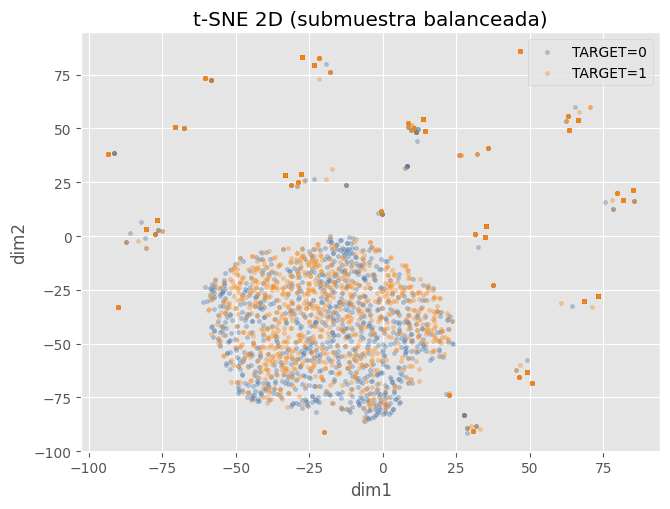

In [24]:
from sklearn.manifold import TSNE

embed_cols = mi_df.head(25)["column"].tolist() if "mi_df" in globals() else num_for_pca[:25]
X_emb = train[embed_cols].copy().fillna(train[embed_cols].median(numeric_only=True))
y_emb = train[y_col].astype(int)

# Muestra controlada para visualización
n0 = min(2500, int((y_emb == 0).sum()))
n1 = min(2500, int((y_emb == 1).sum()))
idx0 = X_emb[y_emb == 0].sample(n0, random_state=42).index
idx1 = X_emb[y_emb == 1].sample(n1, random_state=42).index
idx = idx0.union(idx1)
X_plot = X_emb.loc[idx]
y_plot = y_emb.loc[idx]

# Escalado robusto
X_plot = (X_plot - X_plot.median()) / (X_plot.quantile(0.75) - X_plot.quantile(0.25) + 1e-12)

coords = None
method_used = None
try:
    import umap

    reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, metric="euclidean", random_state=42)
    coords = reducer.fit_transform(X_plot)
    method_used = "UMAP"
except Exception:
    tsne = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto", random_state=42)
    coords = tsne.fit_transform(X_plot)
    method_used = "t-SNE"

emb_df = pd.DataFrame({"dim1": coords[:, 0], "dim2": coords[:, 1], "TARGET": y_plot.values})

fig, ax = plt.subplots(figsize=(6.8, 5.2))
for tval, color, label in [(0, "#4c78a8", "TARGET=0"), (1, "#f58518", "TARGET=1")]:
    ss = emb_df[emb_df["TARGET"] == tval]
    ax.scatter(ss["dim1"], ss["dim2"], s=8, alpha=0.35, c=color, label=label)
ax.set_title(f"{method_used} 2D (submuestra balanceada)")
ax.set_xlabel("dim1")
ax.set_ylabel("dim2")
ax.legend()
plt.tight_layout()

print("Método usado:", method_used, "| filas proyectadas:", len(emb_df), "| columnas:", len(embed_cols))

### Documentación — Artefactos y quality gates del EDA

- Guardamos tablas clave del diagnóstico en `artifacts/metrics/eda_world_class/` para trazabilidad entre corridas.
- Construimos un tablero mínimo de **quality gates** (deriva, significancia, leakage potencial).
- Objetivo: pasar de EDA exploratorio a EDA auditable y reutilizable en pipeline.

In [25]:
out_dir = project_root() / "artifacts" / "metrics" / "eda_world_class"
out_dir.mkdir(parents=True, exist_ok=True)

saved = []
for name, df in [
    ("drift_ks.csv", drift if "drift" in globals() else None),
    ("drift_psi.csv", psi_df if "psi_df" in globals() else None),
    ("cat_assoc.csv", cat_assoc if "cat_assoc" in globals() else None),
    ("mannwhitney.csv", mw if "mw" in globals() else None),
    ("mi_ranking.csv", mi_df if "mi_df" in globals() else None),
    ("vif_top_mi.csv", vif_df if "vif_df" in globals() else None),
    ("leakage_auc_scan.csv", auc_scan if "auc_scan" in globals() else None),
]:
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        continue
    p = out_dir / name
    df.to_csv(p, index=False)
    saved.append(str(p))

print("Artefactos guardados:")
for p in saved:
    print(" -", p)

# Quality gates mínimos para modelado posterior.
max_psi = float(psi_df["psi"].max()) if "psi_df" in globals() and len(psi_df) else np.nan
adv_auc_gate = float(auc_adv) if "auc_adv" in globals() else np.nan
n_leak_high_auc = int((auc_scan["auc_univariate"] >= 0.80).sum()) if "auc_scan" in globals() and len(auc_scan) else 0

if "drift" in globals() and "ks_qvalue_bh" in drift.columns and len(drift):
    ks_sig_rate = float((drift["ks_qvalue_bh"] < 0.05).mean())
else:
    ks_sig_rate = np.nan

quality_gates = pd.DataFrame(
    [
        {"gate": "max_psi", "value": max_psi, "target": "< 0.25", "status": "OK" if pd.notna(max_psi) and max_psi < 0.25 else "REVISAR"},
        {"gate": "adversarial_auc", "value": adv_auc_gate, "target": "< 0.65", "status": "OK" if pd.notna(adv_auc_gate) and adv_auc_gate < 0.65 else "REVISAR"},
        {"gate": "ks_significant_share", "value": ks_sig_rate, "target": "< 0.30", "status": "OK" if pd.notna(ks_sig_rate) and ks_sig_rate < 0.30 else "REVISAR"},
        {"gate": "n_high_auc_univariate", "value": n_leak_high_auc, "target": "== 0", "status": "OK" if n_leak_high_auc == 0 else "REVISAR"},
    ]
)

quality_gates.to_csv(out_dir / "quality_gates.csv", index=False)
print("\nQuality gates:")
display(quality_gates)

Artefactos guardados:
 - E:\Proyectos\Competencias\Home credit\risk-modeling-q1\artifacts\metrics\eda_world_class\drift_ks.csv
 - E:\Proyectos\Competencias\Home credit\risk-modeling-q1\artifacts\metrics\eda_world_class\drift_psi.csv
 - E:\Proyectos\Competencias\Home credit\risk-modeling-q1\artifacts\metrics\eda_world_class\cat_assoc.csv
 - E:\Proyectos\Competencias\Home credit\risk-modeling-q1\artifacts\metrics\eda_world_class\mannwhitney.csv
 - E:\Proyectos\Competencias\Home credit\risk-modeling-q1\artifacts\metrics\eda_world_class\mi_ranking.csv
 - E:\Proyectos\Competencias\Home credit\risk-modeling-q1\artifacts\metrics\eda_world_class\leakage_auc_scan.csv

Quality gates:


,gate,value,target,status
0,max_psi,0.159876,< 0.25,OK
1,adversarial_auc,0.670268,< 0.65,REVISAR
2,ks_significant_share,0.590476,< 0.30,REVISAR
3,n_high_auc_univariate,0.000000,== 0,OK


### Interpretación de resultados — Sección 11

- Mann-Whitney + q-values BH permiten distinguir señal estadística robusta de ruido por múltiples pruebas.
- MI y VIF combinan valor predictivo con control de redundancia, útil para balancear performance e interpretabilidad.
- UMAP/t-SNE y quality gates ofrecen lectura operativa: separabilidad global, riesgo de deriva y readiness para pasar a modelado.

<a id="sec-12"></a>
## 12. Resumen y siguientes pasos


| Hallazgo | Implicación |
|----------|-------------|
| Clase minoritaria | Estratificar CV; PR-AUC y calibración |
| Nulos por bloques | Imputación / NaN-friendly |
| NA distinto entre TARGET 0/1 | Missing como señal |
| KS train vs test alto | Deriva de datos |
| PSI y adversarial AUC | Medir deriva multivariada antes de entrenar |
| Tablas auxiliares largas | Agregaciones por cliente + tiempo |
| EXT_SOURCE / DAYS_* con corr | Features fuertes |
| Cramér V alto | Encoding / árboles |
| Mann-Whitney/MI con señal fuerte | Priorizar variables robustas para baseline lineal y boosting |
| q-values BH consistentes | Control de falsos descubrimientos en todo el EDA |
| VIF alto en top variables | Reducir redundancia (drop/regularizar) antes de modelos lineales |
| Screening de AUC univariado | Revisar posibles fugas o proxies no permitidos |
| UMAP/t-SNE con solapamiento parcial | Frontera no lineal; calibración y thresholding serán clave |
| Quality gates + artefactos CSV | EDA auditable, trazable y comparable entre corridas |

Siguiente: `02_feature_engineering.ipynb` con restricciones de leakage temporal y validación robusta por segmentos.

### Interpretación de resultados — Sección 12

- El cierre integra evidencia estadística, calidad de datos, riesgo de deriva y señales predictivas en una sola narrativa de decisión.
- Si los hallazgos de esta tabla coinciden con los `quality_gates`, el proyecto está listo para pasar a ingeniería y modelado con criterios claros.
- Si hay discrepancias (por ejemplo, señal alta pero deriva también alta), la prioridad es robustez y gobernanza antes de optimizar performance.

## Resumen Ejecutivo de Principales Hallazgos

1. **Desbalance de clases confirmado**: exige validación estratificada, foco en ROC-AUC/PR-AUC y calibración.
2. **Missingness estructural e informativo**: hay señal en patrones de nulos por clase; conviene incorporar indicadores de missing.
3. **Deriva train-test no trivial**: KS/PSI y validación adversarial deben monitorearse antes de fijar modelos finales.
4. **Señales fuertes consistentes**: `EXT_SOURCE_*`, variables de historial y algunos grupos categóricos muestran poder discriminativo.
5. **Riesgo de redundancia**: VIF y correlaciones altas sugieren selección o regularización para modelos lineales.
6. **Auditoría de leakage necesaria**: variables con señal atípica requieren revisión temporal y de negocio.
7. **EDA listo para handoff técnico**: artefactos guardados y quality gates habilitan transición controlada a feature engineering/modelado.

### Recomendación inmediata

Pasar a `02_feature_engineering.ipynb` aplicando tres reglas: 
- diseño temporal sin fuga,
- monitoreo explícito de drift,
- selección de features balanceando señal, estabilidad y gobernanza.